In [201]:
import numpy as np
from math import pi, sqrt
import matplotlib.pyplot as plt

compare the numerical solution `Ax_grid` with the analytical solution `y_grid`

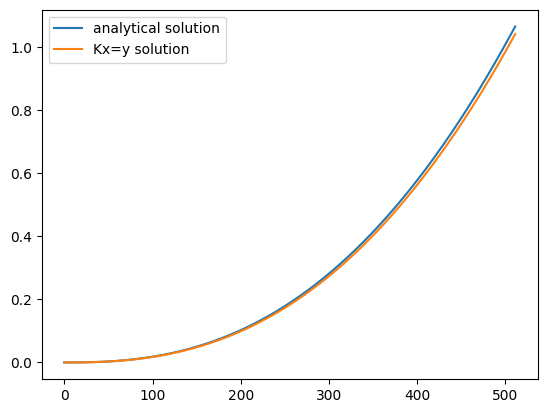

In [202]:
x = lambda s: s**2
y = lambda t: 16/15 * t**(5/2)

N = 512 #stepsize
h = 1/N

s_grid = np.array([i*h + h/2 for i in range(N)])
t_grid = np.array([i*h for i in range(1,N+1)])

# print('s_grid:',s_grid,'\nt_grid:',t_grid)

A = np.zeros((N,N))

for i in range(N):
    for j in range(i+1):
        A[i,j] = h / np.sqrt(t_grid[i] - s_grid[j]) #* k(t[i], s[j])
# print(np.round(A,4))

x_grid = [x(s) for s in s_grid]
# Numerical Solution
Ax_grid = A @ x_grid
# analytical Solution
y_grid = [y(s) for s in s_grid]

plt.plot(y_grid,label="analytical solution")
plt.plot(Ax_grid,label='Kx=y solution')
plt.legend()
plt.show()


add noise `d` to the analytical solution

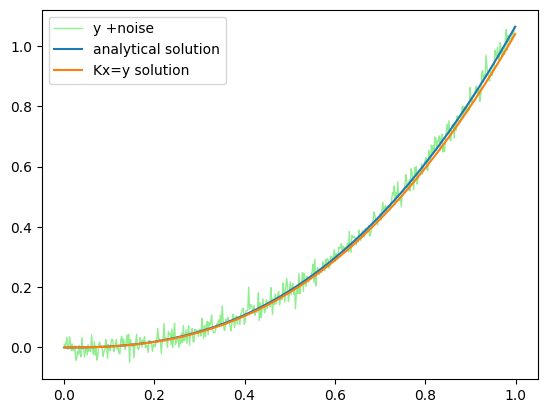

In [203]:
np.random.seed(42)
d = np.random.randn(N)
d = d/np.linalg.norm(d) * 0.05 * np.linalg.norm(y_grid)

y_delta = y_grid + d
plt.plot(s_grid,y_delta,label="y +noise",lw=1,color='lightgreen')
plt.plot(s_grid,y_grid,label="analytical solution")
plt.plot(s_grid,Ax_grid,label='Kx=y solution')
plt.legend()
plt.show()

Solve the inverse problem by TSVD 
and finding out for which k the error is minimal

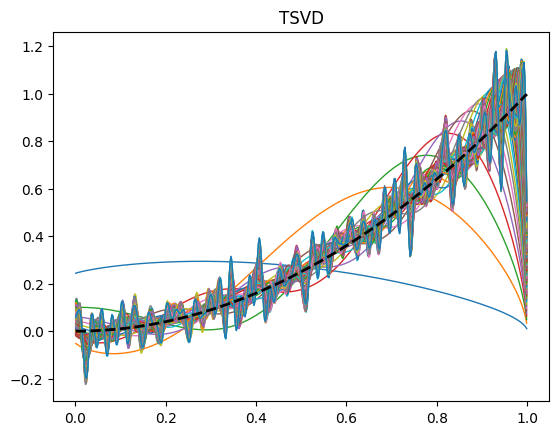

k_min: 44 	 -->(already with right index, as in the exercise)
minError: 0.1260754905805666


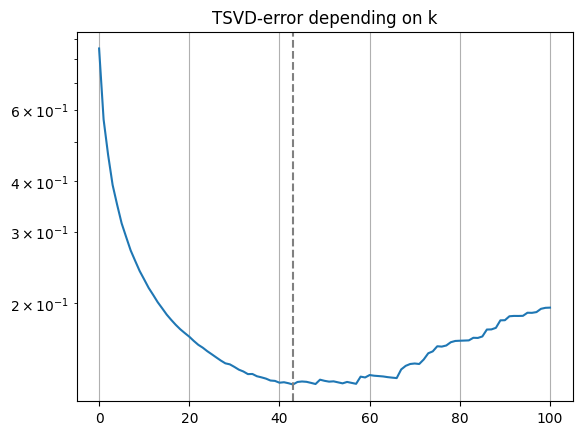

In [204]:
#Ex2 part b)
U, mu, Vt = np.linalg.svd(A)

# region: TSVD
k_top = 10
alpha = 0.01
error_TSVD = np.zeros(min(101,N))

plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2) 

x_TSVD = np.zeros(N)

for k in range(min(101,N)):
    x_TSVD += np.dot(y_delta,U[:,k]) / mu[k] * Vt[k,:]
    # ERROR
    error_TSVD[k] = np.linalg.norm(x_grid - x_TSVD) / np.linalg.norm(x_grid)
    # PLOT
    plt.plot(s_grid,x_TSVD, label=f"x_{k+1}",lw=1)


plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2) 
# plt.legend()
plt.title("TSVD")
plt.show()

#TSVD Error
k_min = np.argmin(error_TSVD)
minError_TSVD = np.min(error_TSVD)
# minError depending on k 
print("k_min:",k_min+1,"\t -->(already with right index, as in the exercise)")
print("minError:",minError_TSVD)


plt.semilogy(error_TSVD)
plt.axvline(k_min,linestyle="--",color="grey")
plt.title("TSVD-error depending on k")
plt.grid(True)
plt.show()
#endregion

Doing Tikhonov, solving minimization problem, for
$$
\underset{x}{min}
\left\|
\begin{pmatrix}
A \\
\sqrt{\alpha}I
\end{pmatrix}
x
-
\begin{pmatrix}
y \\
0
\end{pmatrix}
\right\|^2
$$

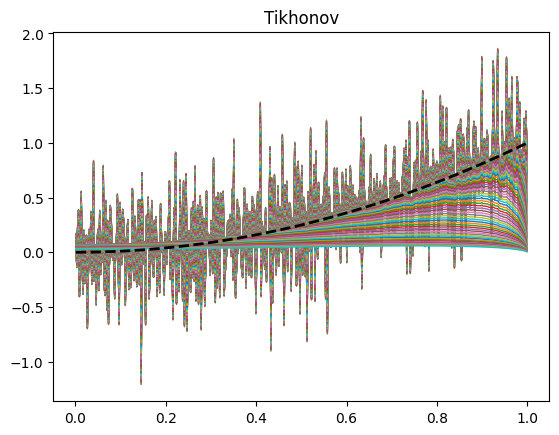

In [209]:
# region: Tikhonov
k_top = 100
# alpha = 0.01
a_array = 10**np.linspace(-4,1,k_top)

error_Tik = np.zeros(len(a_array))
for k,alpha in enumerate(a_array):
    A_Tik = np.vstack([A,np.sqrt(alpha) * np.eye(N)])
    y_Tik = np.concatenate([y_delta,np.zeros(N)])
    
    x_Tik, residuals, rank, s = np.linalg.lstsq(A_Tik, y_Tik, rcond=None)
    error_Tik[k] = np.linalg.norm(x_grid - x_Tik) / np.linalg.norm(x_grid)

    plt.plot(s_grid,x_Tik,label=f"x_alpha with alpha={alpha}",lw=1)
plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2) 

# plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2) 
# plt.legend()
plt.title("Tikhonov")
plt.show()
#endregion

compute smallest relative error for Tikhonov

best alpha = 0.026560877829466867
relative error = 0.1571831930757137


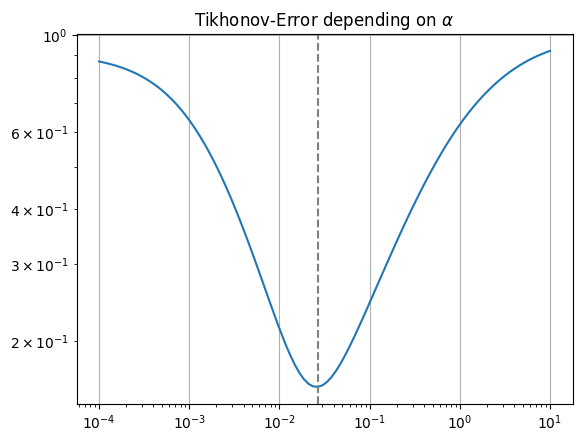

In [210]:
min_index = np.argmin(error_Tik)
alpha_opt = a_array[min_index]
min_error = error_Tik[min_index]

print("best alpha =", alpha_opt)
print("relative error =", min_error)

plt.loglog(a_array,error_Tik)
plt.title("Tikhonov-Error depending on $\\alpha$")
plt.axvline(alpha_opt,linestyle="--",color="grey")
plt.grid(True)
plt.show()

## Alternative Version: 
Tikhonov computed via sum, instead of "least-square-method"
$$
x_{\alpha} = \sum_j \frac{\mu_j}{\mu_j^2 + \alpha} (y^{\delta},y_j)x_j
$$

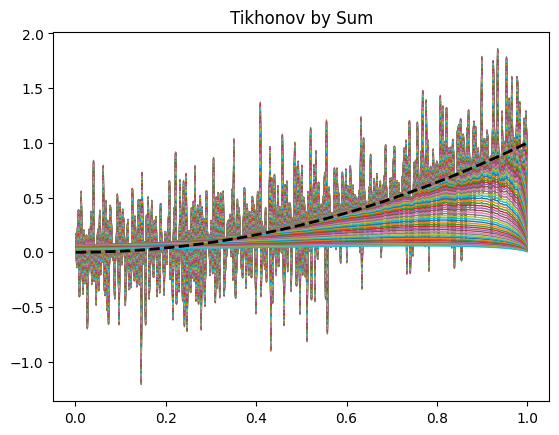

In [221]:
# ALTERNATIVE VERSION via SUM - does not work!!!
k_top = 100
a_array = 10**np.linspace(-4,1,k_top)

plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2) 
errorTikSum = np.zeros(k_top)
for i,a in enumerate(a_array):
    x_TikSum = np.zeros(N)

    for k in range(N):
        factor = mu[k] / (mu[k]**2 + a)
        x_TikSum += factor * np.dot(y_delta,U[:,k]) * Vt[k,:]
    errorTikSum[i] = np.linalg.norm(x_grid - x_TikSum) / np.linalg.norm(x_grid)

    plt.plot(s_grid,x_TikSum, label=f"x_{a}",lw=1)

plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2)
plt.title("Tikhonov by Sum") 
plt.plot();

best alpha = 0.026560877829466867
relative error = 0.15718319307571366


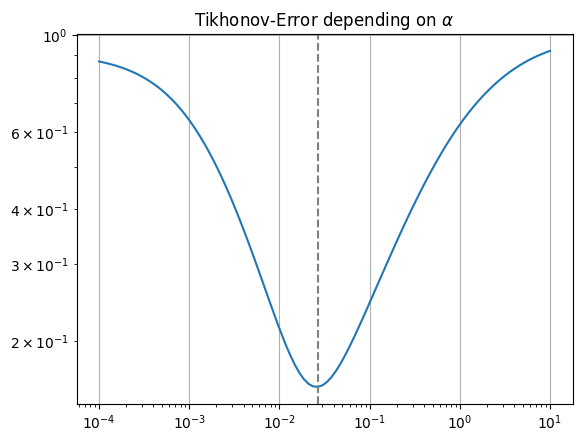

In [ ]:
min_index_TikSum = np.argmin(errorTikSum)
alphaOpt_TikSum = a_array[min_index_TikSum]
minError_TikSum = errorTikSum[min_index_TikSum]

print("best alpha =", alphaOpt_TikSum)
print("relative error =", minError_TikSum)

plt.loglog(a_array,errorTikSum)
plt.title("Tikhonov-Error depending on $\\alpha$ (by Sum)")
plt.axvline(alphaOpt_TikSum,linestyle="--",color="grey")
plt.grid(True)
plt.show()